In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#2e7d32', 'Rabi': '#f9a825', 'Zaid': '#c62828'}

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing values: 120
Duplicate rows: 0


In [6]:
print("Seasons present:", df['Season'].unique())
print()
print(df['Season'].value_counts())

Seasons present: ['Kharif' 'Rabi' 'Zaid']

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [8]:
df_clean = df.copy()

# Standardize text columns
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

# Fill missing numeric values with column median
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Drop exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Enforce categorical season order
df_clean['Season'] = pd.Categorical(df_clean['Season'], categories=SEASON_ORDER, ordered=True)

print("Cleaned shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())
df_clean.head()


Cleaned shape: (4000, 28)
Remaining missing values: 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [9]:
summary_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Rainfall_mm',
                'Avg_Temperature_C', 'Humidity_pct', 'Fertilizer_kg_ha',
                'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

seasonal_summary = df_clean.groupby('Season', observed=True)[summary_cols].mean().round(2)
seasonal_summary


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Fertilizer_kg_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,
Kharif,5.63,46.31,178914.65,849.20,28.45,71.81,187.08,6102.20,5.89,54.47
Rabi,5.04,41.49,87689.47,437.62,23.49,57.89,185.41,5846.99,5.19,40.48
Zaid,4.64,38.89,-24804.82,304.65,31.04,52.01,184.64,6419.89,4.41,38.22


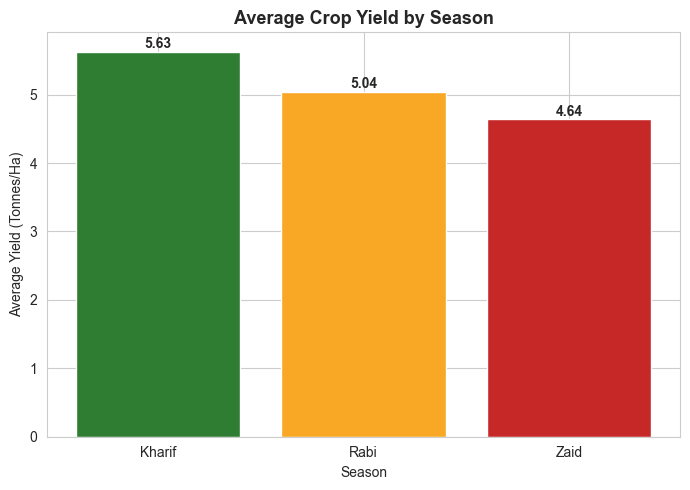

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


In [10]:
yield_by_season = df_clean.groupby('Season', observed=True)['Yield_Tonnes_Ha'].mean().reindex(SEASON_ORDER)

plt.figure(figsize=(7,5))
bars = plt.bar(yield_by_season.index, yield_by_season.values,
               color=[SEASON_COLORS[s] for s in yield_by_season.index])
plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
for bar, val in zip(bars, yield_by_season.values):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.05, f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(yield_by_season)


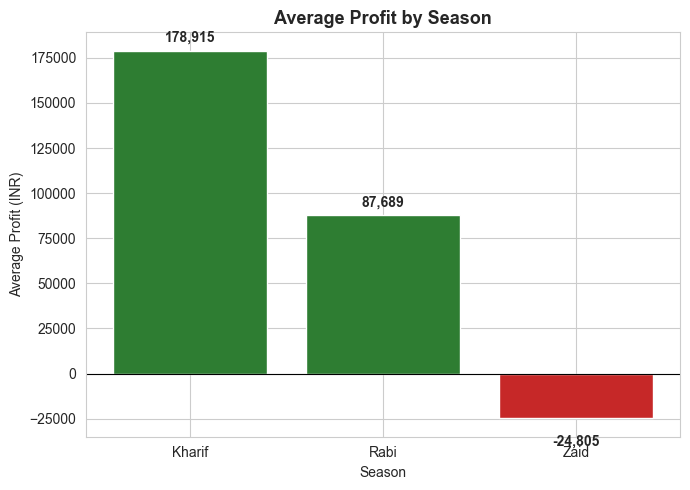

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


In [11]:
profit_by_season = df_clean.groupby('Season', observed=True)['Profit_INR'].mean().reindex(SEASON_ORDER)

plt.figure(figsize=(7,5))
colors = ['#2e7d32' if v >= 0 else '#c62828' for v in profit_by_season.values]
bars = plt.bar(profit_by_season.index, profit_by_season.values, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
for bar, val in zip(bars, profit_by_season.values):
    plt.text(bar.get_x()+bar.get_width()/2, val + (5000 if val>=0 else -15000),
              f'{val:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(profit_by_season)



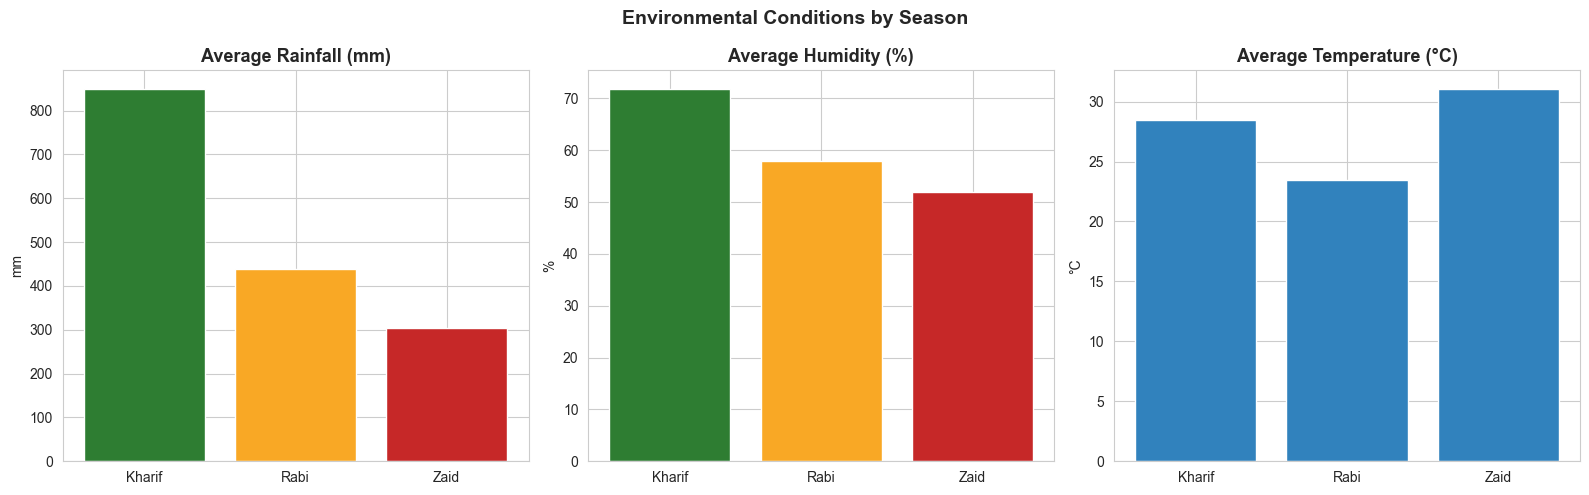

        Rainfall_mm  Humidity_pct  Avg_Temperature_C
Season                                              
Kharif   849.199663     71.812591          28.454019
Rabi     437.615366     57.893178          23.489183
Zaid     304.654714     52.012121          31.042088


In [16]:
env_by_season = df_clean.groupby('Season', observed=True)[['Rainfall_mm','Humidity_pct','Avg_Temperature_C']].mean().reindex(SEASON_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(16,5))

axes[0].bar(env_by_season.index, env_by_season['Rainfall_mm'], color=[SEASON_COLORS[s] for s in SEASON_ORDER])
axes[0].set_title('Average Rainfall (mm)')
axes[0].set_ylabel('mm')

axes[1].bar(env_by_season.index, env_by_season['Humidity_pct'], color=[SEASON_COLORS[s] for s in SEASON_ORDER])
axes[1].set_title('Average Humidity (%)')
axes[1].set_ylabel('%')

axes[2].bar(env_by_season.index, env_by_season['Avg_Temperature_C'], color='#3182BD',)
axes[2].set_title('Average Temperature (°C)')
axes[2].set_ylabel('°C')

plt.suptitle('Environmental Conditions by Season', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(env_by_season)

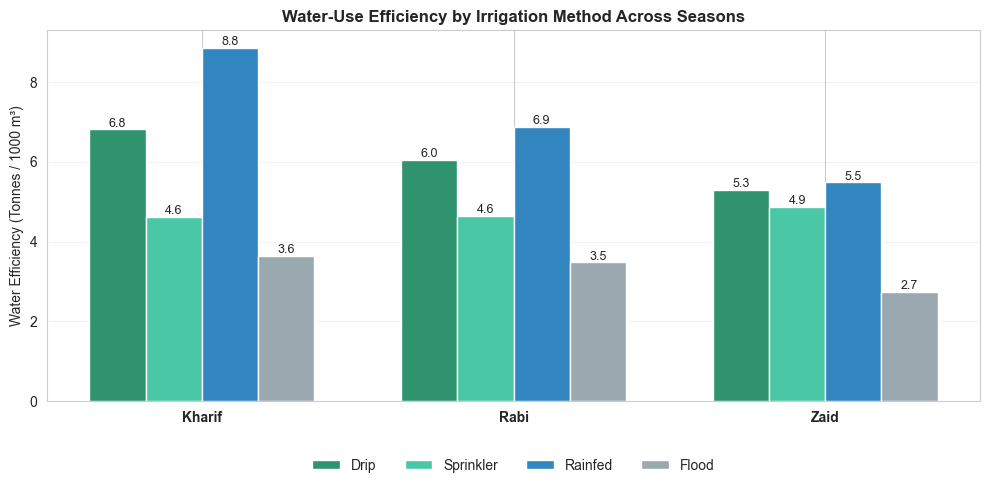

Irrigation_Method      Drip  Sprinkler   Rainfed     Flood
Season                                                    
Kharif             6.803817   4.622022  8.847592  3.637156
Rabi               6.047157   4.644232  6.872941  3.477690
Zaid               5.295921   4.860067  5.479400  2.730469


In [18]:

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
METHODS = ['Drip', 'Sprinkler', 'Rainfed', 'Flood']
COLORS = ['#2F936E', '#4AC8A5', '#3186BF', '#9AA8B0']

water_eff = (df_clean.groupby(['Season', 'Irrigation_Method'], observed=True)
             ['Water_Efficiency_t_per_1000m3'].mean()
             .unstack().reindex(SEASON_ORDER)[METHODS])

fig, ax = plt.subplots(figsize=(10, 5))
x, width = np.arange(3), 0.18

for i, method in enumerate(METHODS):
    bars = ax.bar(x + (i-1.5)*width, water_eff[method], width,
                  label=method, color=COLORS[i])
    for bar, val in zip(bars, water_eff[method]):
        ax.text(bar.get_x()+bar.get_width()/2, val+.08,
                f'{val:.1f}', ha='center', fontsize=9)

ax.set_title('Water-Use Efficiency by Irrigation Method Across Seasons',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Water Efficiency (Tonnes / 1000 m³)')
ax.set_xticks(x)
ax.set_xticklabels(SEASON_ORDER, fontweight='bold')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(.5, -.12), frameon=False)
ax.grid(axis='y', alpha=.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(water_eff)

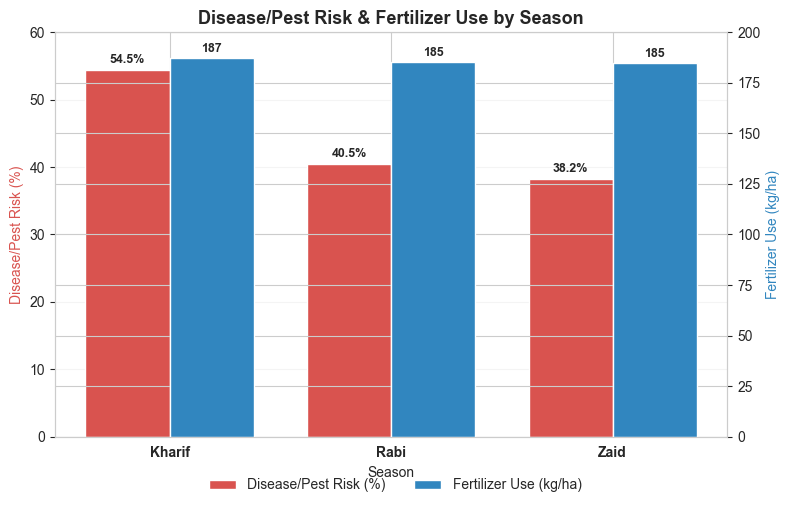

        Disease_Pest_Risk_pct  Fertilizer_kg_ha
Season                                         
Kharif              54.467903        187.077965
Rabi                40.482114        185.407068
Zaid                38.216667        184.638047


In [25]:
risk_fert = (df_clean.groupby('Season', observed=True)
             [['Disease_Pest_Risk_pct', 'Fertilizer_kg_ha']]
             .mean().reindex(SEASON_ORDER))

fig, ax1 = plt.subplots(figsize=(8, 5))
x = np.arange(len(SEASON_ORDER))
w = 0.38

# Bars
b1 = ax1.bar(x-w/2, risk_fert['Disease_Pest_Risk_pct'], w, color='#d9534f', label='Disease/Pest Risk (%)')

ax2 = ax1.twinx()
b2 = ax2.bar(x+w/2, risk_fert['Fertilizer_kg_ha'], w,color='#3186bf', label='Fertilizer Use (kg/ha)')

# Labels
ax1.set_ylabel('Disease/Pest Risk (%)', color='#d9534f')
ax2.set_ylabel('Fertilizer Use (kg/ha)', color='#3186bf')
ax1.set_xlabel('Season')
ax1.set_xticks(x)
ax1.set_xticklabels(SEASON_ORDER, fontweight='bold')

# Values
for b, v in zip(b1, risk_fert['Disease_Pest_Risk_pct']):
    ax1.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%',ha='center', fontsize=9, fontweight='bold')

for b, v in zip(b2, risk_fert['Fertilizer_kg_ha']):
    ax2.text(b.get_x()+b.get_width()/2, v+3, f'{v:.0f}',ha='center', fontsize=9, fontweight='bold')

ax1.set_ylim(0, 60)
ax2.set_ylim(0, 200)

plt.title('Disease/Pest Risk & Fertilizer Use by Season',fontweight='bold')

ax1.grid(axis='y', alpha=.2)
fig.legend(loc='lower center', ncol=2, bbox_to_anchor=(.5, -.02),frameon=False)

plt.tight_layout()
plt.show()

print(risk_fert)

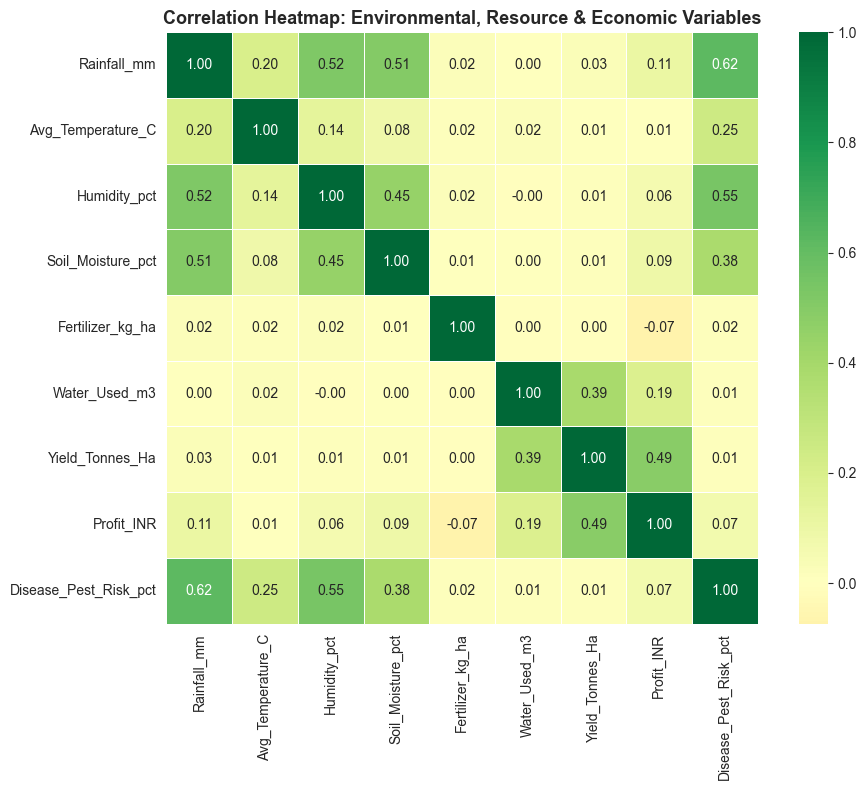

In [21]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
             'Fertilizer_kg_ha','Water_Used_m3','Yield_Tonnes_Ha',
             'Profit_INR','Disease_Pest_Risk_pct']

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=.5, square=True)

plt.title('Correlation Heatmap: Environmental, Resource & Economic Variables',
          fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Season-wise average profit and yield for all crops (extra cross-check)
crop_season = df_clean.groupby(['Season','Crop'], observed=True)['Profit_INR'].mean().unstack()
crop_season.round(0)

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,954380.0,217000.0,108265.0,-39333.0,43339.0,-64903.0,1000791.0,-105872.0
Rabi,638572.0,107344.0,10417.0,-89133.0,-14309.0,-98428.0,731613.0,-119955.0
Zaid,448659.0,-53925.0,-68872.0,-194049.0,-139228.0,-227239.0,583636.0,-193209.0
